In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from decision_tree import DecisionTree, permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score



Setting a seed to be able to recreate results

In [2]:
np.random.seed(42)

In [3]:
data = np.genfromtxt("churn-data.csv", delimiter=",", dtype=float, names=True)
feature_names = list(data.dtype.names[:-1])
target_name = data.dtype.names[-1]
X = np.array([data[feature] for feature in feature_names]).T
y = data[target_name].astype(int)

In [4]:
print(f"Feature columns names: {feature_names}")
print(f"Target column name: {target_name}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

Feature columns names: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']
Target column name: Churn
X shape: (7032, 19)
y shape: (7032,)


In [5]:
X_train, X_valtest, y_train, y_valtest = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_valtest, y_valtest, test_size=0.5, random_state=42)


In [6]:
#model = DecisionTree(criterion="gini", max_depth=10)
#model2 = DecisionTree(criterion="entropy", max_depth=10)

In [7]:
#root = model.fit(X_val, y_val)
#model.print_tree(root, feature_names)

In [8]:
#root2 = model2.fit(X_val, y_val)
#model2.print_tree(root2, feature_names)

In [9]:
#predictions = model.predict(X_val)

In [10]:
#predictions2 = model2.predict(X_val)

In [11]:
#predictions.count(0), predictions.count(1)

In [12]:
#predictions2.count(0), predictions2.count(1)

In [13]:
#y_true = np.asarray(y_val).ravel()
#y_pred = np.asarray(predictions).ravel()  # Use your prediction variable

#assert y_true.shape == y_pred.shape

#print("Correct:", np.sum(y_pred == y_true))
#print("Predicted zeros:", np.sum(y_pred == 0))
#print("Actual zeros:", np.sum(y_true == 0))
#print("Predicted labels:", np.unique(y_pred, return_counts=True))
#print("Correct ones: ", np.sum((y_pred == 1) & y_true == 1))

In [14]:
#y_true = np.asarray(y_val).ravel()
#y_pred_entropy = np.asarray(predictions2).ravel()  # Use your prediction variable

#assert y_true.shape == y_pred.shape

#print("Correct:", np.sum(y_pred_entropy == y_true))
#print("Predicted zeros:", np.sum(y_pred_entropy == 0))
#print("Actual zeros:", np.sum(y_true == 0))
#print("Predicted labels:", np.unique(y_pred_entropy, return_counts=True))
#print("Correct ones: ", np.sum((y_pred_entropy == 1) & y_true == 1))

In [15]:
#print("Different predictions:", np.sum(y_pred != y_pred_entropy))

In [16]:
depths = [1, 2, 3, 4, 5, 6, 8, 10, 20, 40, None]

models = [
    DecisionTree(criterion=criterion, max_depth=depth)
    for criterion in ["gini", "entropy"]
    for depth in depths
]


In [17]:
criteria = {model.criterion for model in models}

# sorted doesn't support nontype, so just did a quick-fix and excluded it 
max_depths = sorted({model.max_depth for model in models if model.max_depth is not None})

print(f"Criteria:   {criteria}")
print(f"Max depths: {max_depths} and None")
print(f"Total models to train: {len(criteria) * len(max_depths) + 2}") # +2 for the max_depth=None

Criteria:   {'entropy', 'gini'}
Max depths: [1, 2, 3, 4, 5, 6, 8, 10, 20, 40] and None
Total models to train: 22


In [18]:
results = []
best_entropy_model = None
best_entropy_f1 = -1
best_entropy_result = None

best_gini_model = None
best_gini_f1 = -1
best_gini_result = None

In [19]:
for model in models:
    model.fit(X_train, y_train)
    predictions = model.predict(X_val)

    acc = accuracy_score(y_val, predictions)
    f1 = f1_score(y_val, predictions, pos_label=1)

    result = {
        "criterion": model.criterion,
        "max_depth": model.max_depth,
        "accuracy": acc,
        "f1_score": f1,
    }
    results.append(result)

    # Lagrer beste modell for hvert kriterium
    if model.criterion == "entropy":
        if f1 > best_entropy_f1:
            best_entropy_f1 = f1
            best_entropy_model = model
            best_entropy_result = result
    elif model.criterion == "gini":
        if f1 > best_gini_f1:
            best_gini_f1 = f1
            best_gini_model = model
            best_gini_result = result

    print(f"criterion={model.criterion:8s} max_depth={str(model.max_depth):4s}  accuracy={acc:.4f}  f1={f1:.4f}")

# Velger beste modell totalt sett, entropy vinner ved uavgjort
if best_entropy_f1 >= best_gini_f1:
    best_model = best_entropy_model
    best_result = best_entropy_result
else:
    best_model = best_gini_model
    best_result = best_gini_result


criterion=gini     max_depth=1     accuracy=0.7511  f1=0.0000
criterion=gini     max_depth=2     accuracy=0.7397  f1=0.5694
criterion=gini     max_depth=3     accuracy=0.7596  f1=0.5101
criterion=gini     max_depth=4     accuracy=0.7952  f1=0.4783
criterion=gini     max_depth=5     accuracy=0.8065  f1=0.5723
criterion=gini     max_depth=6     accuracy=0.8037  f1=0.5818
criterion=gini     max_depth=8     accuracy=0.7866  f1=0.5342
criterion=gini     max_depth=10    accuracy=0.7653  f1=0.5479
criterion=gini     max_depth=20    accuracy=0.7354  f1=0.5000
criterion=gini     max_depth=40    accuracy=0.7340  f1=0.4960
criterion=gini     max_depth=None  accuracy=0.7340  f1=0.4960
criterion=entropy  max_depth=1     accuracy=0.7511  f1=0.0000
criterion=entropy  max_depth=2     accuracy=0.7397  f1=0.5694
criterion=entropy  max_depth=3     accuracy=0.7596  f1=0.5101
criterion=entropy  max_depth=4     accuracy=0.7952  f1=0.4783
criterion=entropy  max_depth=5     accuracy=0.8065  f1=0.5723
criterio

In [20]:
results_df = pd.DataFrame(results)
results_df_sorted = results_df.sort_values(by=["f1_score", "accuracy"], ascending=False)
results_df_sorted.round(4)

,criterion,max_depth,accuracy,f1_score
5,gini,6.0,0.8037,0.5818
16,entropy,6.0,0.8037,0.5818
4,gini,5.0,0.8065,0.5723
15,entropy,5.0,0.8065,0.5723
1,gini,2.0,0.7397,0.5694
12,entropy,2.0,0.7397,0.5694
7,gini,10.0,0.7653,0.5479
17,entropy,8.0,0.7923,0.5350
6,gini,8.0,0.7866,0.5342
18,entropy,10.0,0.7610,0.5200


In [21]:
print("BEST MODEL:")
print(f"Criterion: {best_model.criterion}")
print(f"Max depth: {best_model.max_depth}")
print(f"Accuracy: {best_result['accuracy']:.4f}")
print(f"F1-score: {best_result['f1_score']:.4f}")


BEST MODEL:
Criterion: entropy
Max depth: 6
Accuracy: 0.8037
F1-score: 0.5818


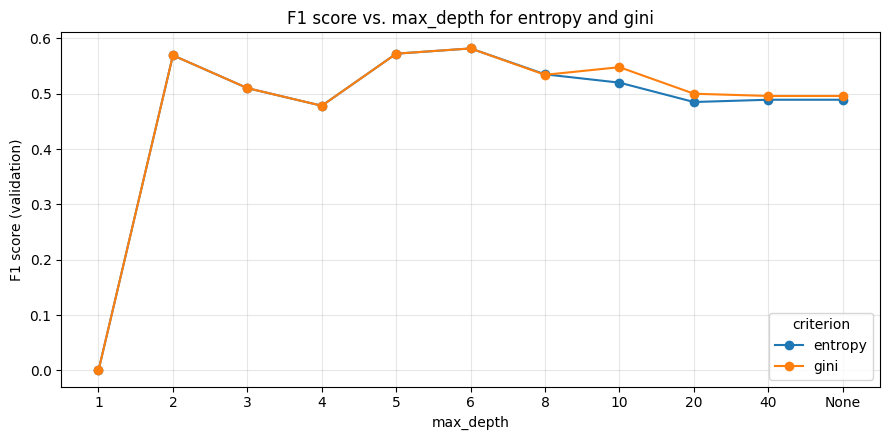

In [22]:
#Generated with ChatGPT, same with all plots


plot_df = results_df.copy()
plot_df['depth_label'] = plot_df['max_depth'].apply(lambda d: 'None' if pd.isna(d) else str(int(d)))

fig, ax = plt.subplots(figsize=(9, 4.5))
for criterion, group in plot_df.groupby('criterion'):
    ax.plot(group['depth_label'], group['f1_score'], marker="o", label=criterion)
ax.set_xlabel('max_depth')
ax.set_ylabel('F1 score (validation)')
ax.set_title('F1 score vs. max_depth for entropy and gini')
ax.legend(title='criterion')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Flere plot for å sammenligne dybder og modeller

Under her ser vi på det samme resultatet fra flere vinkler: accuracy vs. dybde, om modellene overfitter ved høy dybde, og hvordan den beste modellen faktisk generaliserer til det uberørte test-settet.

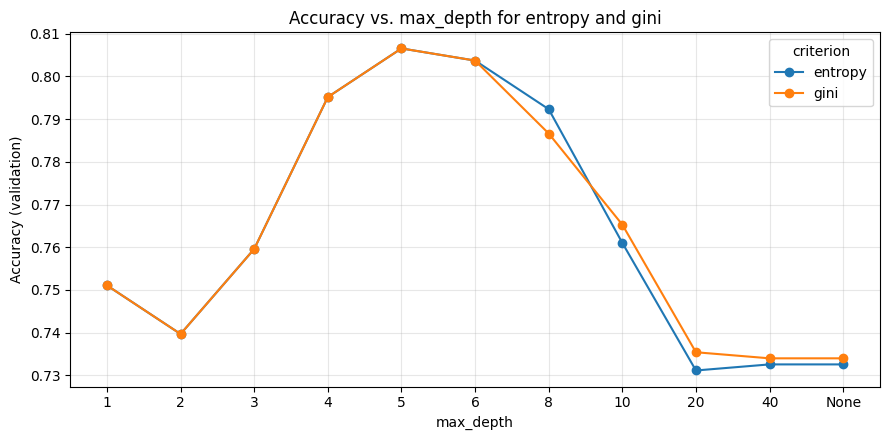

In [23]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for criterion, group in plot_df.groupby('criterion'):
    ax.plot(group['depth_label'], group['accuracy'], marker="o", label=criterion)
ax.set_xlabel('max_depth')
ax.set_ylabel('Accuracy (validation)')
ax.set_title('Accuracy vs. max_depth for entropy and gini')
ax.legend(title='criterion')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Merk:** ved `max_depth=1` er accuracy relativt høy (0.728), men F1-scoren er 0.0. Det er fordi treet da bare gjetter "ingen churn" på alt (den vanligste klassen), noe som gir høy accuracy på et ubalansert datasett uten å faktisk fange opp churn-kundene. Dette viser hvorfor F1-score er et bedre mål enn accuracy her.

### Overfitting: trenings-accuracy vs. validerings-accuracy

For å se om høy `max_depth` fører til overfitting, trener vi samme modeller igjen og sammenligner accuracy på treningssettet med accuracy på valideringssettet.

In [24]:
overfit_results = []

for model in models:
    model = DecisionTree(criterion=model.criterion, max_depth=model.max_depth)
    model.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, model.predict(X_train))
    val_acc = accuracy_score(y_val, model.predict(X_val))

    overfit_results.append({
        'criterion': model.criterion,
        'max_depth': model.max_depth,
        'train_accuracy': train_acc,
        'val_accuracy': val_acc,
    })

overfit_df = pd.DataFrame(overfit_results)
overfit_df['depth_label'] = overfit_df['max_depth'].apply(lambda d: 'None' if pd.isna(d) else str(int(d)))
overfit_df.round(4).sort_values(['max_depth']).head(5)

,criterion,max_depth,train_accuracy,val_accuracy,depth_label
0,gini,1.0,0.7342,0.7511,1
11,entropy,1.0,0.7342,0.7511,1
12,entropy,2.0,0.7467,0.7397,2
1,gini,2.0,0.7467,0.7397,2
2,gini,3.0,0.7808,0.7596,3


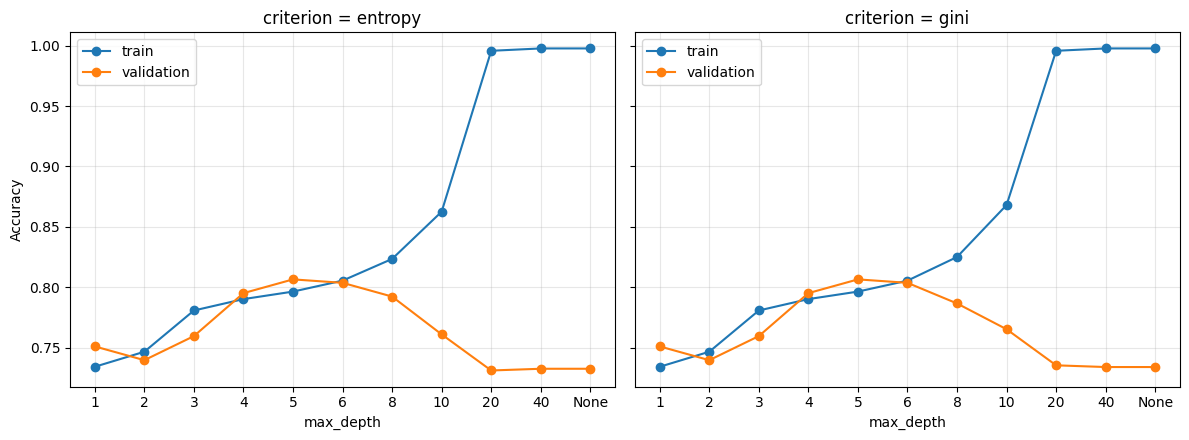

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

for ax, (criterion, group) in zip(axes, overfit_df.groupby('criterion')):
    ax.plot(group['depth_label'], group["train_accuracy"], marker='o', label='train')
    ax.plot(group['depth_label'], group["val_accuracy"], marker='o', label='validation')
    ax.set_title(f'criterion = {criterion}')
    ax.set_xlabel('max_depth')
    ax.grid(alpha=0.3)
    ax.legend()

axes[0].set_ylabel('Accuracy')
plt.tight_layout()
plt.show()

### Beste modell mot det uberørte test-settet

Til nå har `X_test`/`y_test` ikke blitt brukt til noe. Vi trener den beste konfigurasjonen (fra `best`) på treningssettet og evaluerer den én gang på test-settet, for å se om resultatet vårt faktisk generaliserer.

criterion=entropy, max_depth=6
Test accuracy: 0.7642
Test F1 score: 0.5632


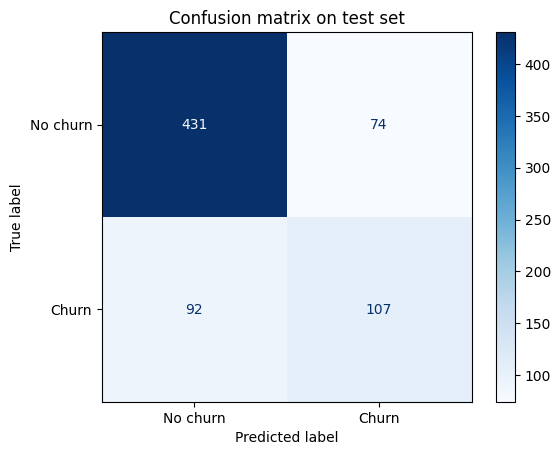

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

test_predictions = best_model.predict(X_test)

test_acc = accuracy_score(y_test, test_predictions)
test_f1 = f1_score(y_test, test_predictions, pos_label=1)
print(f'criterion={best_model.criterion}, max_depth={best_model.max_depth}')
print(f'Test accuracy: {test_acc:.4f}')
print(f'Test F1 score: {test_f1:.4f}')

cm = confusion_matrix(y_test, test_predictions)
disp = ConfusionMatrixDisplay(cm, display_labels=['No churn', 'Churn'])
disp.plot(cmap='Blues')
plt.title('Confusion matrix on test set')
plt.show()

In [27]:
from sklearn.tree import DecisionTreeClassifier

sk_results = []
sk_best_entropy_model = None
sk_best_entropy_f1 = -1
sk_best_entropy_result = None

sk_best_gini_model = None
sk_best_gini_f1 = -1
sk_best_gini_result = None

In [28]:
for criterion in ["gini", "entropy"]:
    for depth in depths:
        sk_model = DecisionTreeClassifier(criterion=criterion, max_depth=depth, random_state=42)
        sk_model.fit(X_train, y_train)
        predictions = sk_model.predict(X_val)

        acc = accuracy_score(y_val, predictions)
        f1 = f1_score(y_val, predictions, pos_label=1)

        result = {
            "criterion": criterion,
            "max_depth": depth,
            "accuracy": acc,
            "f1_score": f1,
        }
        sk_results.append(result)

        if criterion == "entropy":
            if f1 > sk_best_entropy_f1:
                sk_best_entropy_f1 = f1
                sk_best_entropy_model = sk_model
                sk_best_entropy_result = result
        elif criterion == "gini":
            if f1 > sk_best_gini_f1:
                sk_best_gini_f1 = f1
                sk_best_gini_model = sk_model
                sk_best_gini_result = result

        print(f"criterion={criterion:8s} max_depth={str(depth):4s}  accuracy={acc:.4f}  f1={f1:.4f}")

if sk_best_entropy_f1 >= sk_best_gini_f1:
    sk_best_model = sk_best_entropy_model
    sk_best_result = sk_best_entropy_result
else:
    sk_best_model = sk_best_gini_model
    sk_best_result = sk_best_gini_result

print()
print("BEST SKLEARN MODEL:")
print(f"Criterion: {sk_best_model.criterion}")
print(f"Max depth: {sk_best_model.max_depth}")
print(f"Accuracy: {sk_best_result['accuracy']:.4f}")
print(f"F1-score: {sk_best_result['f1_score']:.4f}")


criterion=gini     max_depth=1     accuracy=0.7511  f1=0.0000
criterion=gini     max_depth=2     accuracy=0.7397  f1=0.5694
criterion=gini     max_depth=3     accuracy=0.7795  f1=0.4151
criterion=gini     max_depth=4     accuracy=0.7610  f1=0.5670
criterion=gini     max_depth=5     accuracy=0.8023  f1=0.5413
criterion=gini     max_depth=6     accuracy=0.7824  f1=0.5378
criterion=gini     max_depth=8     accuracy=0.7866  f1=0.5399
criterion=gini     max_depth=10    accuracy=0.7667  f1=0.5148
criterion=gini     max_depth=20    accuracy=0.7169  f1=0.4665
criterion=gini     max_depth=40    accuracy=0.7283  f1=0.4796
criterion=gini     max_depth=None  accuracy=0.7283  f1=0.4796
criterion=entropy  max_depth=1     accuracy=0.7511  f1=0.0000
criterion=entropy  max_depth=2     accuracy=0.7397  f1=0.5694
criterion=entropy  max_depth=3     accuracy=0.7795  f1=0.4151
criterion=entropy  max_depth=4     accuracy=0.7610  f1=0.5670
criterion=entropy  max_depth=5     accuracy=0.8023  f1=0.5413
criterio

criterion=entropy, max_depth=2
Test accuracy: 0.7074
Test F1 score: 0.5813


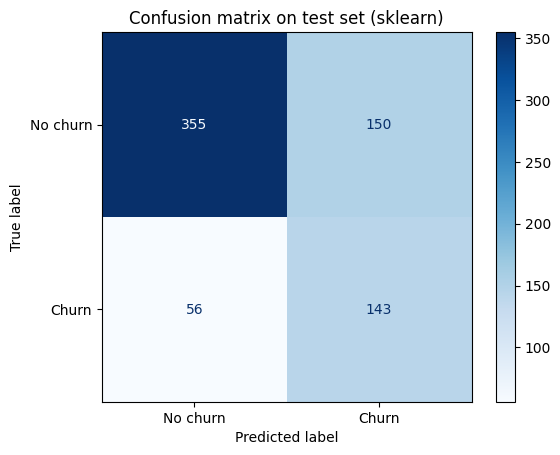

In [29]:
sk_test_predictions = sk_best_model.predict(X_test)

sk_test_acc = accuracy_score(y_test, sk_test_predictions)
sk_test_f1 = f1_score(y_test, sk_test_predictions, pos_label=1)

print(f'criterion={sk_best_model.criterion}, max_depth={sk_best_model.max_depth}')
print(f'Test accuracy: {sk_test_acc:.4f}')
print(f'Test F1 score: {sk_test_f1:.4f}')

cm = confusion_matrix(y_test, sk_test_predictions)
disp = ConfusionMatrixDisplay(cm, display_labels=['No churn', 'Churn'])
disp.plot(cmap='Blues')
plt.title('Confusion matrix on test set (sklearn)')
plt.show()


In [30]:
print("SAMMENLIGNING PÅ Test SETTET")
print(f"Egen implementasjon:  criterion={best_model.criterion:8s} max_depth={str(best_model.max_depth):4s}  accuracy={test_acc:.4f}  f1={test_f1:.4f}")
print(f"sklearn:               criterion={sk_best_model.criterion:8s} max_depth={str(sk_best_model.max_depth):4s}  accuracy={sk_test_acc:.4f}  f1={sk_test_f1:.4f}")


SAMMENLIGNING PÅ Test SETTET
Egen implementasjon:  criterion=entropy  max_depth=6     accuracy=0.7642  f1=0.5632
sklearn:               criterion=entropy  max_depth=2     accuracy=0.7074  f1=0.5813


In [31]:
importances = permutation_importance(best_model, X_test, y_test, accuracy_score, n_repeats=30, seed=42)

for name, score in zip(feature_names, importances):
    print(f"{name:20s} {score:.4f}")


gender               -0.0000
SeniorCitizen        0.0022
Partner              -0.0000
Dependents           -0.0000
tenure               0.0280
PhoneService         -0.0000
MultipleLines        -0.0083
InternetService      0.0226
OnlineSecurity       0.0305
OnlineBackup         0.0287
DeviceProtection     -0.0000
TechSupport          0.0066
StreamingTV          0.0008
StreamingMovies      -0.0000
Contract             0.0213
PaperlessBilling     0.0010
PaymentMethod        -0.0030
MonthlyCharges       -0.0000
TotalCharges         0.0033


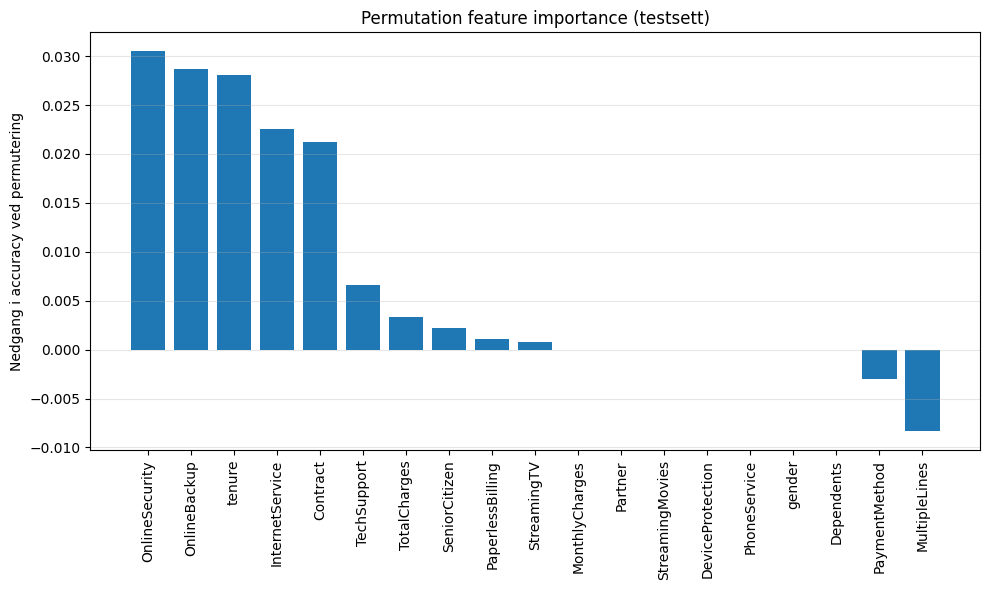

In [32]:
importances = np.array(importances)

sorted_idx = np.argsort(importances)[::-1]
sorted_names = [feature_names[i] for i in sorted_idx]
sorted_importances = importances[sorted_idx]

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(range(len(sorted_importances)), sorted_importances)
ax.set_xticks(range(len(sorted_importances)))
ax.set_xticklabels(sorted_names, rotation=90)
ax.set_ylabel("Nedgang i accuracy ved permutering")
ax.set_title("Permutation feature importance (testsett)")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()
